In [1]:
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max

import astropy.units as u

import sunpy.map
from sunpy.data.sample import AIA_193_IMAGE
from sunpy.map.maputils import all_pixel_indices_from_map

# Carga de la imagen de muestra
aiamap = sunpy.map.Map(AIA_193_IMAGE)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

AIA20110607_063307_0193_lowres.fits:   0%|          | 0.00/1.00M [00:00<?, ?B/s]

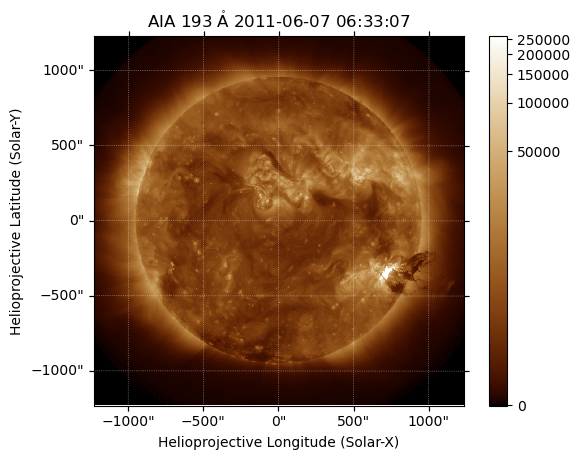

In [2]:
# Creamos una figura vacía para el primer gráfico
fig = plt.figure()

# Añadimos un sub-gráfico usando la proyección WCS astronómica propia de nuestro mapa solar
ax = fig.add_subplot(projection=aiamap)

# Dibujamos el Sol sobre el eje con la configuración de color por defecto de SunPy (escala verde)
aiamap.plot(axes=ax)

# Añadimos una barra lateral para relacionar visualmente los colores con los niveles de intensidad
plt.colorbar()

In [3]:
# Generamos dos matrices (X e Y) que contienen las posiciones de cada píxel de la imagen
X, Y = all_pixel_indices_from_map(aiamap)

# Buscamos los píxeles más brillantes bajo dos restricciones matemáticas estrictas:
# min_distance=60 -> No permite otro pico en un radio de 60 píxeles (evita duplicados en una zona activa)
# threshold_rel=0.2 -> El píxel debe brillar al menos el 20% respecto al punto más brillante de todo el Sol
coordinates = peak_local_max(aiamap.data, min_distance=60, threshold_rel=0.2)

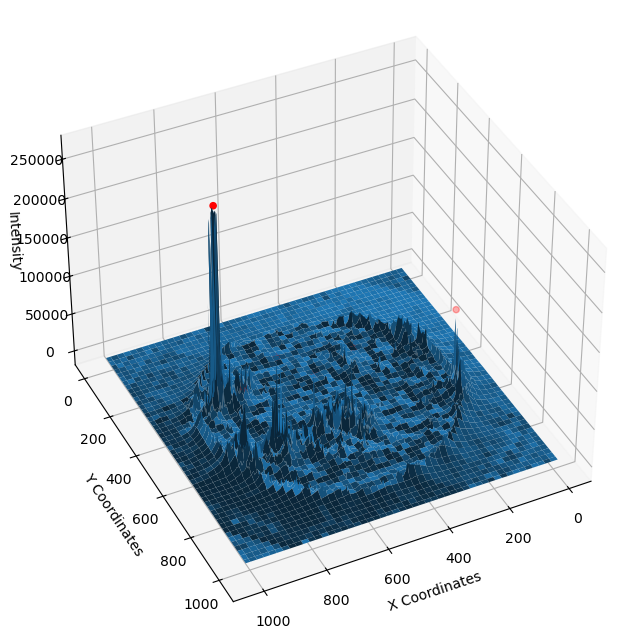

In [4]:
# Definimos una ventana grande (12x8 pulgadas) para apreciar bien el relieve 3D
fig = plt.figure(figsize=(12, 8))

# Añadimos un sub-gráfico configurado explícitamente para proyecciones en tres dimensiones
ax = fig.add_subplot(projection='3d')

# Graficamos la superficie: X e Y son el plano base, aiamap.data da la altura (Z, Intensidad)
ax.plot_surface(X, Y, aiamap.data)

# Rotamos la cámara del gráfico: 39 grados de elevación sobre el horizonte y 64 grados de azimut
ax.view_init(elev=39, azim=64)

# Extraemos los valores de brillo (Z) usando las coordenadas [Fila, Columna] que encontramos
peaks_pos = aiamap.data[coordinates[:, 0], coordinates[:, 1]]

# Dibujamos puntos tridimensionales de color rojo ('r') justo encima de las cimas detectadas
# Nota: Pasamos las columnas primero (X -> coordinates[:, 1]) y luego las filas (Y -> coordinates[:, 0])
ax.scatter(coordinates[:, 1], coordinates[:, 0], peaks_pos, color='r')

# Etiquetas de los tres ejes cartesianos para el entendimiento del gráfico
ax.set_xlabel('X Coordinates')
ax.set_ylabel('Y Coordinates')
ax.set_zlabel('Intensity')

# Mostramos las dos primeras ventanas en pantalla (el mapa 2D inicial y el relieve 3D)
plt.show()

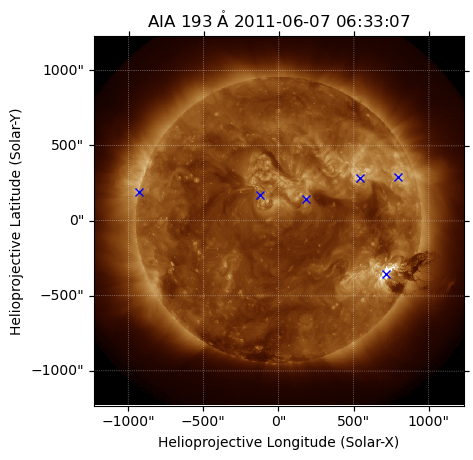

In [5]:
# Transformamos las posiciones de píxeles en coordenadas reales del espacio (Helioproyectivas).
# aiamap.wcs.pixel_to_world lee la calibración del satélite para hacer la conversión matemática.
# Multiplicamos por '* u.pixel' para que el sistema sepa que las entradas son píxeles planos.
hpc_max = aiamap.wcs.pixel_to_world(coordinates[:, 1]*u.pixel, coordinates[:, 0]*u.pixel)

# Preparamos la tercera ventana para la composición final
fig = plt.figure()

# Usamos nuevamente la proyección nativa del Sol (coordenadas astronómicas en los bordes)
ax = fig.add_subplot(projection=aiamap)

# Volvemos a pintar la imagen base del Sol en 2D
aiamap.plot(axes=ax)

# ax.plot_coord interpreta el objeto astronómico 'hpc_max' y dibuja de manera inteligente 
# cruces de color azul ('bx') en los puntos exactos del espacio donde están las regiones activas
ax.plot_coord(hpc_max, 'bx')

# Desplegamos la última ventana con los resultados finales superpuestos
plt.show()